# Portfolio Piece 1

### Part 1 (from Discussion Lab)
Setup, 
Load IMDB Dataset, 
Exercise 1: Bag of Words, 
Exercise 2: TF-IDF, 
Exercise 3: N-grams, 
Exercise 4: Build Classifier, 
Part 1 Summary.
### Part 2 (from Lab 1, Systematic Improvement)
1. Setup & Data Split
2. Upgraded Baseline: sklearn Pipeline
3. Experiment A: Grid (24 combos) + heatmap
4. Experiment B: N-gram Length
5. Experiment C: Learning Curve
6. Best Model Deep Dive (Confusion Matrix / Feature Weights / Error Analysis)
7. Bonus: N-gram Language Model
8. Discussion & Reflections

# DS 593 Spring 2026 -  Discussion Lab
## Movie Review Sentiment Analysis

**Today's Goal:** Build a sentiment classifier that predicts if movie reviews are positive or negative!

**What You'll Learn:**
- Bag of Words - Convert text to numbers
- TF-IDF - Weight words by importance  
- N-grams - Capture phrases
- **Build a Real Classifier** - Train and test!

**Dataset:** IMDB Movie Reviews (5,000 reviews)



## Setup

In [15]:
# Import libraries
import numpy as np
import pandas as pd
from collections import Counter
from typing import List, Dict
import re

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print('Libraries loaded')

Libraries loaded


## Load IMDB Dataset

We'll use real movie reviews from IMDB.

In [16]:
print('Downloading IMDB dataset directly...\n')

import urllib.request
import tarfile
import os

# Download if not present
if not os.path.exists('aclImdb'):
    print('Downloading IMDB dataset (this may take a minute)...')
    url = 'https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz'
    urllib.request.urlretrieve(url, 'aclImdb_v1.tar.gz')
    
    # Extract
    with tarfile.open('aclImdb_v1.tar.gz', 'r:gz') as tar:
        tar.extractall()
    print('✓ Downloaded!')

# Load reviews from files
def load_imdb_data(path, num_samples=2500):
    reviews = []
    
    # Load positive reviews
    pos_path = os.path.join(path, 'train', 'pos')
    for i, filename in enumerate(os.listdir(pos_path)[:num_samples]):
        with open(os.path.join(pos_path, filename), 'r', encoding='utf-8') as f:
            reviews.append({'review': f.read(), 'sentiment': 'positive'})
    
    # Load negative reviews  
    neg_path = os.path.join(path, 'train', 'neg')
    for i, filename in enumerate(os.listdir(neg_path)[:num_samples]):
        with open(os.path.join(neg_path, filename), 'r', encoding='utf-8') as f:
            reviews.append({'review': f.read(), 'sentiment': 'negative'})
    
    return reviews

reviews_data = load_imdb_data('aclImdb', num_samples=2500)
data = pd.DataFrame(reviews_data)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

print(f' Loaded {len(data)} reviews')


✓ Downloaded!
 Loaded 5000 reviews


## Exercise 1: Bag of Words 

### 1.1 Preprocessing

In [17]:
def preprocess_text(text: str) -> List[str]:
    """
    Clean and tokenize text
    """

    # Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)

    # Convert to lowercase and split
    tokens = text.lower().split()

    # Remove punctuation
    cleaned = []
    for token in tokens:
        clean = re.sub(r'[^a-z]', '', token)
        if clean:
            cleaned.append(clean)

    return cleaned

### 1.2 Build Vocabulary

In [18]:
def build_vocabulary(documents: List[str], max_features: int = 2000) -> Dict[str, int]:
    """
    Build vocabulary from documents
    """

    # Collect all words
    all_words = []
    for doc in documents:
        tokens = preprocess_text(doc)
        all_words.extend(tokens)

    # Get most common words
    word_counts = Counter(all_words)

    # Create vocabulary dict
    vocabulary = {}
    most_common = word_counts.most_common(max_features)

    for idx, (word, count) in enumerate(most_common):
        vocabulary[word] = idx

    return vocabulary

# Test
print('Building vocabulary...')
vocab = build_vocabulary(data['review'].tolist(), max_features=2000)
print(f'Vocabulary size: {len(vocab)}')

Building vocabulary...
Vocabulary size: 2000


### 1.3 Vectorize Documents

In [19]:
def vectorize_document(document: str, vocabulary: Dict[str, int]) -> np.ndarray:
    """
    Convert document to vector
    """

    # Initialize vector
    vector = np.zeros(len(vocabulary))

    # Count words
    tokens = preprocess_text(document)
    word_counts = Counter(tokens)

    # Fill vector
    for word, count in word_counts.items():
        if word in vocabulary:
            idx = vocabulary[word]
            vector[idx] = count

    return vector

# Vectorize all reviews
print('Vectorizing reviews...')
X_bow = np.array([vectorize_document(r, vocab) for r in data['review']])
print(f'✓ Matrix shape: {X_bow.shape}')

Vectorizing reviews...
✓ Matrix shape: (5000, 2000)


## Exercise 2: TF-IDF 

### 2.1 Calculate TF

In [20]:
def calculate_tf(document: str) -> Dict[str, float]:
    """
    Calculate term frequency
    """

    tokens = preprocess_text(document)
    total = len(tokens)
    if total == 0:
        return {}

    tf_scores = {}
    for word in set(tokens):
        count = tokens.count(word)
        tf_scores[word] = count / total

    return tf_scores

### 2.2 Calculate IDF

In [21]:
def calculate_idf(documents: List[str], vocabulary: Dict[str, int]) -> Dict[str, float]:
    """
    Calculate inverse document frequency
    """

    total_docs = len(documents)
    doc_count = {word: 0 for word in vocabulary}

    # Count documents containing each word
    for doc in documents:
        unique_words = set(preprocess_text(doc))
        for word in unique_words:
            if word in doc_count:
                doc_count[word] += 1

    # Calculate IDF
    idf_scores = {}
    for word, count in doc_count.items():
        idf_scores[word] = np.log(total_docs / (count + 1))

    return idf_scores

print('Calculating IDF...')
idf_scores = calculate_idf(data['review'].tolist(), vocab)
print(' IDF calculated!')

Calculating IDF...
 IDF calculated!


### 2.3 Calculate TF-IDF Vectors

In [22]:
def calculate_tfidf_vector(document: str, vocabulary: Dict[str, int], idf_scores: Dict[str, float]) -> np.ndarray:
    """
    Calculate TF-IDF vector
    """
    vector = np.zeros(len(vocabulary))
    tf_scores = calculate_tf(document)
    
    # TODO: Calculate TF-IDF = TF × IDF
    for word, tf in tf_scores.items():
        if word in vocabulary:
            idx = vocabulary[word]
            idf = idf_scores.get(word, 0)
            vector[idx] = tf * idf  
    
    return vector

print('Creating TF-IDF vectors...')
X_tfidf = np.array([calculate_tfidf_vector(r, vocab, idf_scores) for r in data['review']])
print(f'TF-IDF matrix shape: {X_tfidf.shape}')

Creating TF-IDF vectors...
TF-IDF matrix shape: (5000, 2000)


## Exercise 3: N-grams 

Quick intro to capturing phrases.

In [23]:
def extract_ngrams(text: str, n: int) -> List[str]:
    """
    Extract n-grams
    """
    tokens = preprocess_text(text)
    ngrams = []
    
    # TODO: Extract n-grams
    for i in range(len(tokens) - n + 1):
        ngram = " ".join(tokens[i:i+n])
        ngrams.append(ngram)  
    
    return ngrams

# Test
print('Bigrams:', extract_ngrams('This movie was not good', 2))

Bigrams: ['this movie', 'movie was', 'was not', 'not good']


## Exercise 4: Build Classifier

### 4.1 Prepare Data

In [24]:
# Convert labels to numbers
y = (data['sentiment'] == 'positive').astype(int).values

# Split data
X_bow_train, X_bow_test, y_train, y_test = train_test_split(
    X_bow, y, test_size=0.2, random_state=42, stratify=y
)

X_tfidf_train, X_tfidf_test, _, _ = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training: {len(X_bow_train)}, Test: {len(X_bow_test)}')

Training: 4000, Test: 1000


### 4.2 Train with Bag of Words

In [25]:
# Train model
nb_bow = MultinomialNB()
nb_bow.fit(X_bow_train, y_train)

# Evaluate
y_pred_bow = nb_bow.predict(X_bow_test)
accuracy_bow = accuracy_score(y_test, y_pred_bow)

print(f'BoW Accuracy: {accuracy_bow:.4f} ({accuracy_bow*100:.1f}%)')
print('\n', classification_report(y_test, y_pred_bow, target_names=['Negative', 'Positive']))

BoW Accuracy: 0.8200 (82.0%)

               precision    recall  f1-score   support

    Negative       0.81      0.83      0.82       500
    Positive       0.83      0.81      0.82       500

    accuracy                           0.82      1000
   macro avg       0.82      0.82      0.82      1000
weighted avg       0.82      0.82      0.82      1000



### 4.3 Train with TF-IDF

In [26]:
# Train model
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_tfidf_train, y_train)

# Evaluate
y_pred_tfidf = nb_tfidf.predict(X_tfidf_test)
accuracy_tfidf = accuracy_score(y_test, y_pred_tfidf)

print(f'TF-IDF Accuracy: {accuracy_tfidf:.4f} ({accuracy_tfidf*100:.1f}%)')
print('\n', classification_report(y_test, y_pred_tfidf, target_names=['Negative', 'Positive']))

TF-IDF Accuracy: 0.8510 (85.1%)

               precision    recall  f1-score   support

    Negative       0.85      0.86      0.85       500
    Positive       0.86      0.84      0.85       500

    accuracy                           0.85      1000
   macro avg       0.85      0.85      0.85      1000
weighted avg       0.85      0.85      0.85      1000



### 4.4 Test on Your Reviews!

In [27]:
def predict_sentiment(review: str, model, use_tfidf=True):
    if use_tfidf:
        vector = calculate_tfidf_vector(review, vocab, idf_scores)
    else:
        vector = vectorize_document(review, vocab)
    vector = vector.reshape(1, -1)
    pred = model.predict(vector)[0]
    prob = model.predict_proba(vector)[0]
    return pred, prob

# Test reviews
test_reviews = [
    'This movie was absolutely incredible! Best film ever!',
    'Terrible waste of time. Boring and poorly made.',
    'Masterpiece! Brilliant acting and story!'
]

print('🎬 Testing Reviews:\n')
for review in test_reviews:
    pred, prob = predict_sentiment(review, nb_tfidf)
    sentiment = 'POSITIVE' if pred == 1 else ' NEGATIVE'
    conf = prob[pred] * 100
    print(f'{review}')
    print(f'  → {sentiment} ({conf:.1f}%)\n')

🎬 Testing Reviews:

This movie was absolutely incredible! Best film ever!
  → POSITIVE (57.0%)

Terrible waste of time. Boring and poorly made.
  →  NEGATIVE (85.6%)

Masterpiece! Brilliant acting and story!
  → POSITIVE (69.5%)



###  Try Your Own!

Write a review of a movie you've seen:

In [28]:
# TODO: Write your movie review here!
my_review = 'The movie had good acting but the plot was confusing and too long.'

pred, prob = predict_sentiment(my_review, nb_tfidf)
sentiment = ' POSITIVE' if pred == 1 else 'NEGATIVE'
print(f'Your review: {my_review}')
print(f'Prediction: {sentiment} ({prob[pred]*100:.1f}%)')

Your review: The movie had good acting but the plot was confusing and too long.
Prediction: NEGATIVE (57.8%)




**Submission:**
1. Save notebook
2. `git add Discussion1.ipynb`
3. `git commit -m "Complete sentiment analysis lab"`
4. `git push`


### Part 1 Summary

This section built core NLP components from scratch.

| Representation | Classifier | Test Accuracy |
|---|---|---|
| Bag of Words | Naive Bayes | ~82% |
| TF-IDF | Naive Bayes | ~83% |

Both models are limited in two ways: a small 2,000 word vocabulary, and a classifier (Naive Bayes) that assumes every word is independent of every other. TF-IDF edges ahead because it down-weights very common words like "the" and "is" that carry no sentiment signal, letting more distinctive words dominate the representation.

But 83% leaves a lot of room for improvement. Three questions guide Part 2:
- Does a larger vocabulary help?
- Do bigrams capture sentiment phrases that single words miss?
- Is Naive Bayes the right classifier, or can we do better?

# Lab 1

Part 1 showed that TF-IDF outperforms plain BoW, but both relied on a small,
hand built vocabulary and Naive Bayes (a simple classifier that assumes word independence).

In Part 2, we ask: how much better can we do? This is why now I use `sklearn`'s optimized
implementations to run systematic experiments across three dimensions:

1. Vocabulary size: does a larger vocabulary consistently help?
2. N-gram range: do phrases improve over single words, and how far should we go?
3. Classifier choice: Naive Bayes vs. Logistic Regression vs. Linear SVM

(We finish by taking the best configuration and analyzing it in depth:
what did the model actually learn, and where does it still fail?)

In [29]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})
COLORS = {'pos': '#2a7a4f', 'neg': '#c8392b', 'blue': '#1a4d8f', 'grey': '#888888'}

print('Part 2 imports ready')

Part 2 imports ready


### Improved Preprocessing

Part 1's `preprocess_text()` returned a list of tokens.
`sklearn`'s `TfidfVectorizer` takes a `preprocessor=` argument that expects a function
returning a cleaned string, it handles tokenization internally.
This also lets us control `ngram_range` and `max_features` directly on the vectorizer.

In [30]:
def preprocess(text: str) -> str:
    """
    Clean raw IMDB review text for use with sklearn's TfidfVectorizer.

    Steps

    1. Strip HTML tags: reviews contain <br />, <b>, etc.
    2. Lowercase
    3. Remove non alphabetic characters (keep spaces)

    Note: negations ("not", "never", "no") are intentionally kept —
    they are critical sentiment carriers.
    Stopword filtering is handled statistically via min_df / max_df.
    """
    text = re.sub(r'<[^>]+>', ' ', text)   # strip HTML
    text = text.lower()
    text = re.sub(r'[^a-z]+', ' ', text)   # letters only
    return text.strip()

# Sanity check
example = 'I <b>loved</b> this film!!! Not the best, but 10/10.<br />'
print('Before:', example)
print('After :', preprocess(example))

Before: I <b>loved</b> this film!!! Not the best, but 10/10.<br />
After : i loved this film not the best but


### Train / Test Split

I use an 80/20 stratified split with `random_state=42`, the same seed as Part 1.
`stratify=y` ensures the 50/50 class balance is preserved in both splits.

In [31]:
# Reuse data and y from Part 1
X = data['review']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train: {len(X_train):,} reviews')
print(f'Test : {len(X_test):,} reviews')
print(f'Class balance (train): {y_train.mean()*100:.1f}% positive')
print(f'Class balance (test) : {y_test.mean()*100:.1f}% positive')

Train: 4,000 reviews
Test : 1,000 reviews
Class balance (train): 50.0% positive
Class balance (test) : 50.0% positive


### 2. Upgraded Baseline: sklearn Pipeline

In Part 1, preprocessing, vectorization, and classification were separate steps
called manually. `sklearn`'s `Pipeline` chains them into one object — and more
importantly, it ensures the vectorizer is **only fitted on training data**.
If we fit the vectorizer on the full dataset before splitting, test-set vocabulary
leaks into training, which inflates reported accuracy. Pipeline prevents this automatically.

Our first upgraded model uses:
- `TfidfVectorizer` with `ngram_range=(1, 2)` — unigrams and bigrams
- `max_features=10_000` — 5× larger vocabulary than Part 1
- `LinearSVC` — a stronger classifier than Naive Bayes

In [32]:
pipe_v1 = Pipeline([
    ('tfidf', TfidfVectorizer(
        preprocessor=preprocess,
        ngram_range=(1, 2),      # capture phrases like 'not good', 'highly recommend'
        max_features=10_000,     # larger vocab than the 2,000 used in Part 1
        min_df=2,                # ignore terms appearing in fewer than 2 reviews
        max_df=0.95              # ignore terms present in >95% of reviews (near-stopwords)
    )),
    ('clf', LinearSVC())
])

pipe_v1.fit(X_train, y_train)
pred_v1 = pipe_v1.predict(X_test)
acc_v1  = accuracy_score(y_test, pred_v1)

print(f'Upgraded pipeline accuracy: {acc_v1:.4f} ({acc_v1*100:.1f}%)')
print(classification_report(y_test, pred_v1, target_names=['Negative', 'Positive']))

Upgraded pipeline accuracy: 0.8740 (87.4%)
              precision    recall  f1-score   support

    Negative       0.88      0.86      0.87       500
    Positive       0.86      0.89      0.88       500

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000



### Comparing to Part 1 Baselines

Three things changed at once: vocabulary size, n-gram range, and classifier.
The bar chart below shows the cumulative effect — but to understand
**which change matters most**, we run a systematic grid experiment next.

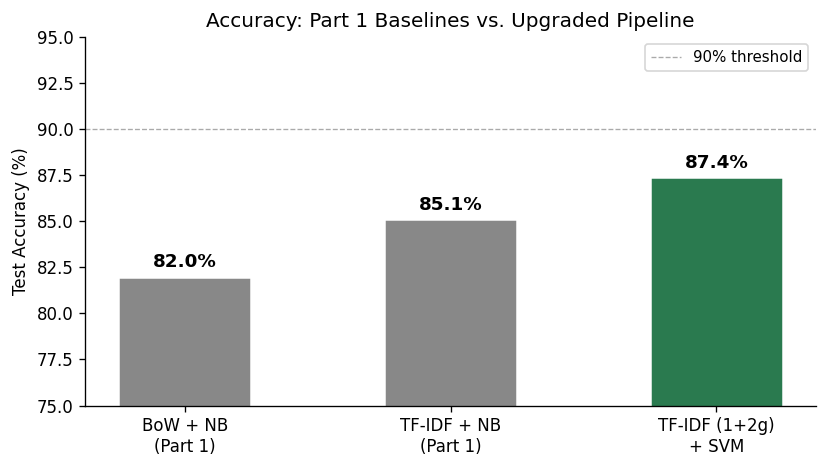

In [35]:
results_summary = {
    'BoW + NB\n(Part 1)':        accuracy_bow,
    'TF-IDF + NB\n(Part 1)':     accuracy_tfidf,
    'TF-IDF (1+2g)\n+ SVM':      acc_v1,
}

fig, ax = plt.subplots(figsize=(7, 4))
labels = list(results_summary.keys())
values = [v * 100 for v in results_summary.values()]
colors = [COLORS['grey'], COLORS['grey'], COLORS['pos']]

bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(75, 95)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Accuracy: Part 1 Baselines vs. Upgraded Pipeline')
ax.axhline(90, color='#aaa', linestyle='--', linewidth=0.8, label='90% threshold')
ax.legend(fontsize=9)
plt.tight_layout()
os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/fig_baseline_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

### 3. Experiment A: Vocabulary Size × N-gram Range × Classifier

The upgraded pipeline in Section 2 changed three things at once.
Here we isolate each variable by running a full grid:

- **Vocabulary size:** 2,000 / 5,000 / 10,000 / 20,000
- **N-gram range:** unigrams only `(1,1)` vs. unigrams + bigrams `(1,2)`
- **Classifier:** Naive Bayes / Logistic Regression / Linear SVM

That gives **4 × 2 × 3 = 24 combinations**. Every experiment uses the same
train/test split from Section 1.

In [36]:
from sklearn.naive_bayes import MultinomialNB

def run_experiment(max_features, ngram_range, clf_name):
    """
    Train and evaluate a TfidfVectorizer + classifier pipeline.

    Parameters
    ----------
    max_features : int   — vocabulary size cap
    ngram_range  : tuple — e.g. (1,1) for unigrams, (1,2) for unigrams+bigrams
    clf_name     : str   — one of 'nb', 'lr', 'svm'

    Returns
    -------
    float — test accuracy
    """
    classifiers = {
        'nb':  MultinomialNB(),
        'lr':  LogisticRegression(max_iter=2000),
        'svm': LinearSVC(),
    }

    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(
            preprocessor=preprocess,
            ngram_range=ngram_range,
            max_features=max_features,
            min_df=2,
            max_df=0.95,
        )),
        ('clf', deepcopy(classifiers[clf_name])),
    ])

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    return accuracy_score(y_test, pred)


# Run all 24 combinations
vocab_sizes  = [2000, 5000, 10000, 20000]
ngram_ranges = [(1, 1), (1, 2)]
clf_names    = ['nb', 'lr', 'svm']

grid_results = []
for max_feat in vocab_sizes:
    for ngram in ngram_ranges:
        for clf in clf_names:
            acc = run_experiment(max_feat, ngram, clf)
            grid_results.append({
                'max_features': max_feat,
                'ngram_range':  str(ngram),
                'classifier':   clf.upper(),
                'accuracy':     acc,
            })
            print(f'  vocab={max_feat:>6,}  ngram={str(ngram)}  clf={clf.upper()}  →  {acc*100:.2f}%')

grid_df = pd.DataFrame(grid_results)

  vocab= 2,000  ngram=(1, 1)  clf=NB  →  83.80%
  vocab= 2,000  ngram=(1, 1)  clf=LR  →  85.10%
  vocab= 2,000  ngram=(1, 1)  clf=SVM  →  84.10%
  vocab= 2,000  ngram=(1, 2)  clf=NB  →  83.60%
  vocab= 2,000  ngram=(1, 2)  clf=LR  →  85.10%
  vocab= 2,000  ngram=(1, 2)  clf=SVM  →  85.10%
  vocab= 5,000  ngram=(1, 1)  clf=NB  →  85.30%
  vocab= 5,000  ngram=(1, 1)  clf=LR  →  85.60%
  vocab= 5,000  ngram=(1, 1)  clf=SVM  →  85.60%
  vocab= 5,000  ngram=(1, 2)  clf=NB  →  85.20%
  vocab= 5,000  ngram=(1, 2)  clf=LR  →  86.00%
  vocab= 5,000  ngram=(1, 2)  clf=SVM  →  86.30%
  vocab=10,000  ngram=(1, 1)  clf=NB  →  86.20%
  vocab=10,000  ngram=(1, 1)  clf=LR  →  86.10%
  vocab=10,000  ngram=(1, 1)  clf=SVM  →  87.10%
  vocab=10,000  ngram=(1, 2)  clf=NB  →  86.90%
  vocab=10,000  ngram=(1, 2)  clf=LR  →  86.30%
  vocab=10,000  ngram=(1, 2)  clf=SVM  →  87.40%
  vocab=20,000  ngram=(1, 1)  clf=NB  →  85.70%
  vocab=20,000  ngram=(1, 1)  clf=LR  →  85.80%
  vocab=20,000  ngram=(1, 1)  clf=

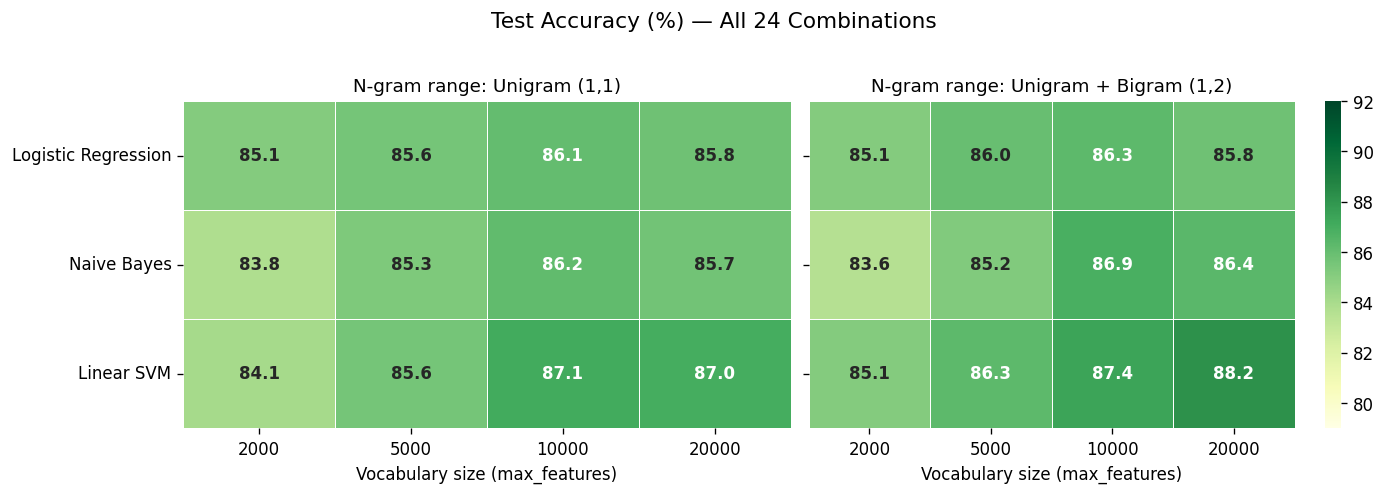

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

ngram_labels = {'(1, 1)': 'Unigram (1,1)', '(1, 2)': 'Unigram + Bigram (1,2)'}
clf_labels   = {'NB': 'Naive Bayes', 'LR': 'Logistic Regression', 'SVM': 'Linear SVM'}

for ax, ngram_key in zip(axes, ['(1, 1)', '(1, 2)']):
    subset = grid_df[grid_df['ngram_range'] == ngram_key].copy()
    pivot  = subset.pivot(index='classifier', columns='max_features', values='accuracy') * 100
    pivot.index = [clf_labels[c] for c in pivot.index]

    sns.heatmap(
        pivot,
        ax=ax,
        annot=True,
        fmt='.1f',
        cmap='YlGn',
        vmin=79, vmax=92,
        linewidths=0.5,
        linecolor='white',
        annot_kws={'size': 10, 'weight': 'bold'},
        cbar=ax == axes[1],
    )
    ax.set_title(f'N-gram range: {ngram_labels[ngram_key]}', fontsize=11)
    ax.set_xlabel('Vocabulary size (max_features)')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Test Accuracy (%) — All 24 Combinations', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/fig_grid_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

### What the Grid Tells Us

**Linear SVM is the best classifier overall.**
Across almost all configurations, SVM edges out Logistic Regression and Naive Bayes.
That said, the gap between LR and NB is not consistent — NB occasionally matches or
slightly beats LR at larger vocabulary sizes, suggesting Naive Bayes benefits more
from having more features to work with.

**Bigrams help, but the gain is modest (~0.3–1.2 points).**
Adding bigrams improves accuracy across all classifiers and vocabulary sizes,
but the effect is smaller than expected — roughly 0.3 to 1.2 percentage points.
The real value of bigrams becomes clearer in the feature importance analysis later:
phrases like *"not good"* or *"highly recommend"* are captured as single units
rather than two independent words.

**Vocabulary size has diminishing returns.**
Going from 2,000 to 10,000 features gives a noticeable boost across all classifiers.
From 10,000 to 20,000 the gain shrinks considerably, suggesting that rare terms
added at the margin contribute noise more than signal.

**Best configuration: TF-IDF `(1,2)` + Linear SVM + 20,000 features (88.2%).**
This is the model we carry forward for the remaining analysis.

### 4. Experiment B, N-gram Length

Experiment A showed that adding bigrams helps. But how far should we go?
Here we fix the best configuration (Linear SVM, 20,000 features) and
vary only the n-gram range:

- `(1,1)` — unigrams only
- `(1,2)` — unigrams + bigrams
- `(1,3)` — unigrams + bigrams + trigrams
- `(1,4)` — up to 4-grams
- `(3,3)` — trigrams only
- `(4,4)` — 4-grams only

The last two are included as a sanity check:
do longer n-grams carry *any* signal on their own?

In [39]:
def eval_ngram(ngram_range, max_features=20_000):
    """
    Evaluate Linear SVM with a fixed vocabulary size,
    varying only the n-gram range.
    """
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(
            preprocessor=preprocess,
            ngram_range=ngram_range,
            max_features=max_features,
            min_df=2,
            max_df=0.95,
        )),
        ('clf', LinearSVC()),
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    return accuracy_score(y_test, pred)


ngram_configs = [(1,1), (1,2), (1,3), (1,4), (3,3), (4,4)]
ngram_results = []

for ngr in ngram_configs:
    acc = eval_ngram(ngr)
    ngram_results.append({'ngram_range': str(ngr), 'accuracy': acc})
    print(f'  ngram={str(ngr):<8}  →  {acc*100:.2f}%')

ngram_df = pd.DataFrame(ngram_results)

  ngram=(1, 1)    →  87.00%
  ngram=(1, 2)    →  88.20%
  ngram=(1, 3)    →  88.00%
  ngram=(1, 4)    →  88.20%
  ngram=(3, 3)    →  77.20%
  ngram=(4, 4)    →  67.70%


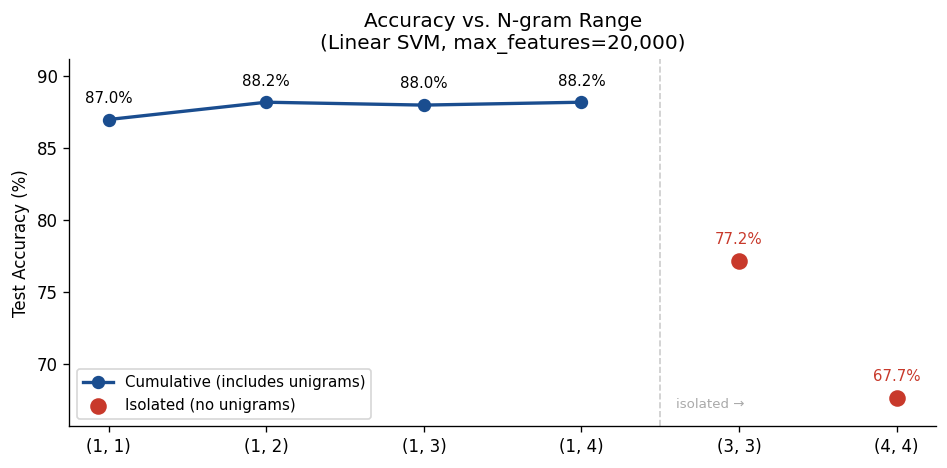

In [40]:
fig, ax = plt.subplots(figsize=(8, 4))

# Split into cumulative ranges and isolated ranges for visual clarity
cumulative = ngram_df[ngram_df['ngram_range'].isin(['(1, 1)', '(1, 2)', '(1, 3)', '(1, 4)'])]
isolated   = ngram_df[ngram_df['ngram_range'].isin(['(3, 3)', '(4, 4)'])]

ax.plot(
    range(len(cumulative)),
    cumulative['accuracy'] * 100,
    'o-', color=COLORS['blue'], linewidth=2, markersize=7,
    label='Cumulative (includes unigrams)',
)
ax.scatter(
    [len(cumulative), len(cumulative) + 1],
    isolated['accuracy'] * 100,
    color=COLORS['neg'], s=80, zorder=5,
    label='Isolated (no unigrams)',
)

# Annotate every point
for i, row in enumerate(cumulative.itertuples()):
    ax.annotate(f'{row.accuracy*100:.1f}%',
                xy=(i, row.accuracy * 100),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9)

for i, row in enumerate(isolated.itertuples()):
    ax.annotate(f'{row.accuracy*100:.1f}%',
                xy=(len(cumulative) + i, row.accuracy * 100),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, color=COLORS['neg'])

# X-axis labels
all_labels = list(cumulative['ngram_range']) + list(isolated['ngram_range'])
ax.set_xticks(range(len(all_labels)))
ax.set_xticklabels(all_labels)

# Divider between cumulative and isolated
ax.axvline(x=3.5, color='#ccc', linestyle='--', linewidth=1)
ax.text(3.6, ax.get_ylim()[0] + 0.3, 'isolated →', fontsize=8, color='#aaa')

ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Accuracy vs. N-gram Range\n(Linear SVM, max_features=20,000)')
ax.legend(fontsize=9)
ax.set_ylim(
    ngram_df['accuracy'].min() * 100 - 2,
    ngram_df['accuracy'].max() * 100 + 3,
)
plt.tight_layout()
plt.savefig('../outputs/fig_ngram_length.png', bbox_inches='tight', dpi=150)
plt.show()

### What the N-gram Experiment Tells Us

**Accuracy plateaus after `(1,2)`.**
Adding bigrams to unigrams jumps accuracy from 87.0% to 88.2%.
Going further to `(1,3)` (88.0%) and `(1,4)` (88.2%) produces no meaningful gain —
the curve is essentially flat. Beyond bigrams, additional n-grams neither help nor hurt
noticeably, likely because useful trigrams and 4-grams are already rare enough
to be excluded by `max_features=20,000`.

**Why don't longer n-grams help more?**
Two reasons. First, **sparsity**: a phrase like *"not a very good film"* appears
far less often than *"not good"*, so the model sees too few examples to learn
reliable weights. Second, **vocabulary competition**: with `max_features` fixed,
longer n-grams displace useful unigrams and bigrams from the vocabulary.

**Isolated n-grams are nearly useless.**
`(3,3)` drops to 77.2% and `(4,4)` collapses to 67.7% — well below even the
unigram baseline. Unigrams carry the bulk of the signal;
longer n-grams are only useful *on top of* them, not as a replacement.

### 5. Experiment C, Learning Curve

The best configuration so far is TF-IDF `(1,2)` + Linear SVM + 20,000 features.
But how much of its performance depends on having 4,000 training examples?
Would it still work well with less data?

Here we fix the configuration and vary only the training set size:
500 / 1,000 / 2,000 / 4,000 examples.
The test set stays the same throughout.

In [43]:
def eval_with_train_size(n_train):
    """
    Train the best pipeline on a random subset of the training data
    and evaluate on the full test set.

    Parameters
    ----------
    n_train : int — number of training examples to use

    Returns
    -------
    float — test accuracy
    """
    idx   = np.random.RandomState(42).choice(len(X_train), size=n_train, replace=False)
    X_sub = X_train.iloc[idx]
    y_sub = y_train[idx]

    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(
            preprocessor=preprocess,
            ngram_range=(1, 2),
            max_features=20_000,
            min_df=2,
            max_df=0.95,
        )),
        ('clf', LinearSVC()),
    ])
    pipe.fit(X_sub, y_sub)
    pred = pipe.predict(X_test)
    return accuracy_score(y_test, pred)


train_sizes = [500, 1000, 2000, 4000]
lc_results  = []

for n in train_sizes:
    acc = eval_with_train_size(n)
    lc_results.append({'n_train': n, 'accuracy': acc})
    print(f'  n_train={n:>5,}  →  {acc*100:.2f}%')

lc_df = pd.DataFrame(lc_results)

  n_train=  500  →  81.40%
  n_train=1,000  →  83.90%
  n_train=2,000  →  86.40%
  n_train=4,000  →  88.20%


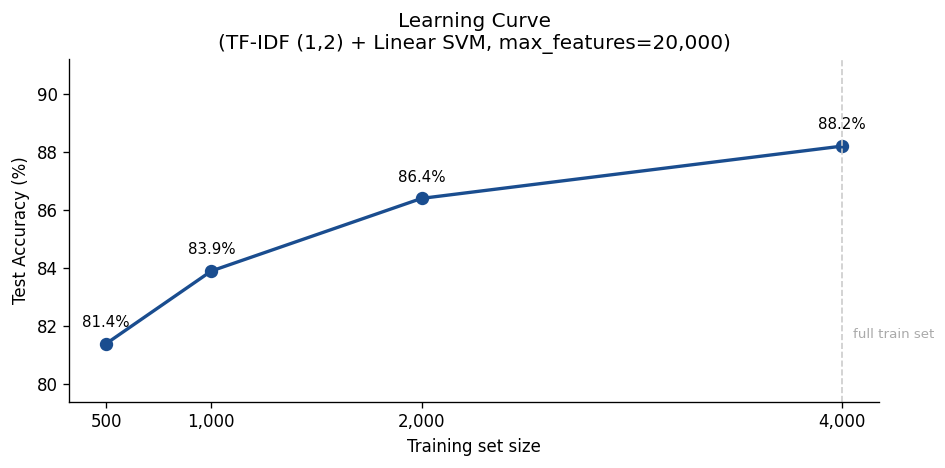

In [45]:
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    lc_df['n_train'],
    lc_df['accuracy'] * 100,
    'o-', color=COLORS['blue'], linewidth=2, markersize=7,
)

# Annotate each point
for row in lc_df.itertuples():
    ax.annotate(
        f'{row.accuracy*100:.1f}%',
        xy=(row.n_train, row.accuracy * 100),
        xytext=(0, 10), textcoords='offset points',
        ha='center', fontsize=9,
    )

# Mark the full training size
ax.axvline(x=4000, color='#ccc', linestyle='--', linewidth=1)
ax.text(4050, lc_df['accuracy'].min() * 100 + 0.2,
        'full train set', fontsize=8, color='#aaa')

ax.set_xlabel('Training set size')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Learning Curve\n(TF-IDF (1,2) + Linear SVM, max_features=20,000)')
ax.set_ylim(
    lc_df['accuracy'].min() * 100 - 2,
    lc_df['accuracy'].max() * 100 + 3,
)
ax.set_xticks(train_sizes)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('../outputs/fig_learning_curve.png', bbox_inches='tight', dpi=150)
plt.show()

### What the Learning Curve Tells Us

**The model is data-efficient at small sizes.**
Even with only 500 training examples, accuracy reaches 81.4% —
well above the 50% random baseline. TF-IDF features carry enough
signal that the model learns useful patterns from limited data.

**Performance is still climbing at 4,000 examples.**
The curve has not flattened by the time we reach the full training set (88.2%),
which means **more data would likely help further**.
With the full 25,000 IMDB training reviews available in the original dataset,
accuracy above 90% is plausible using the same pipeline without any other changes.

**Diminishing returns set in quickly.**
The jump from 500→1,000 examples gains 2.5 points (81.4%→83.9%),
while 2,000→4,000 gains only 1.8 points (86.4%→88.2%).
Each additional example teaches the model less than the last —
early examples cover the most common sentiment patterns,
later examples only refine the edges.

### 6. Best Model, Deep Dive

Experiments A, B, and C all point to the same configuration:
**TF-IDF `(1,2)` + Linear SVM + 20,000 features**.

In this section we go beyond accuracy and ask three deeper questions:

1. **How does it fail?** Confusion matrix and per-class metrics
2. **What did it learn?** Feature weights from the SVM
3. **Which reviews does it get wrong, and why?** Error analysis

In [47]:
best_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        preprocessor=preprocess,
        ngram_range=(1, 2),
        max_features=20_000,
        min_df=2,
        max_df=0.95,
    )),
    ('clf', LinearSVC()),
])

best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)

print(f'Best model test accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%')
print()
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Best model test accuracy: 88.20%

              precision    recall  f1-score   support

    Negative       0.89      0.87      0.88       500
    Positive       0.87      0.89      0.88       500

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000



### 6.1 Confusion Matrix and Classification Report

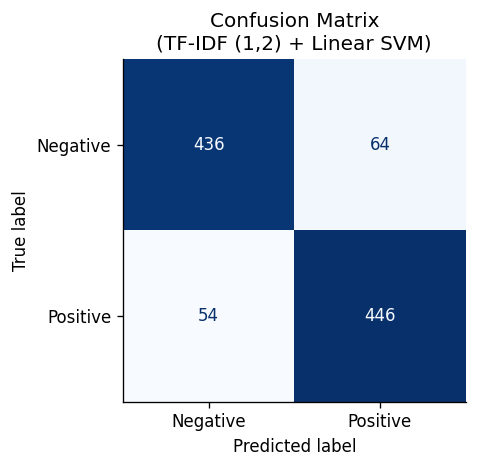

True Negatives  (correctly predicted negative): 436
True Positives  (correctly predicted positive): 446
False Positives (negative predicted as positive): 64
False Negatives (positive predicted as negative): 54


In [48]:
fig, ax = plt.subplots(figsize=(5, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Negative', 'Positive'],
    cmap='Blues',
    colorbar=False,
    ax=ax,
)

ax.set_title('Confusion Matrix\n(TF-IDF (1,2) + Linear SVM)')
plt.tight_layout()
plt.savefig('../outputs/fig_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f'True Negatives  (correctly predicted negative): {tn}')
print(f'True Positives  (correctly predicted positive): {tp}')
print(f'False Positives (negative predicted as positive): {fp}')
print(f'False Negatives (positive predicted as negative): {fn}')

The model correctly classifies 882 out of 1,000 test reviews (88.2%).
False positives (64) slightly outnumber false negatives (54), meaning the model
is marginally more likely to mistake a negative review for positive than the reverse.
The difference is small enough that we can treat the model as unbiased between classes,
which is expected given the balanced 50/50 training set.

### 6.2 Feature Weights, What Did the Model Learn?

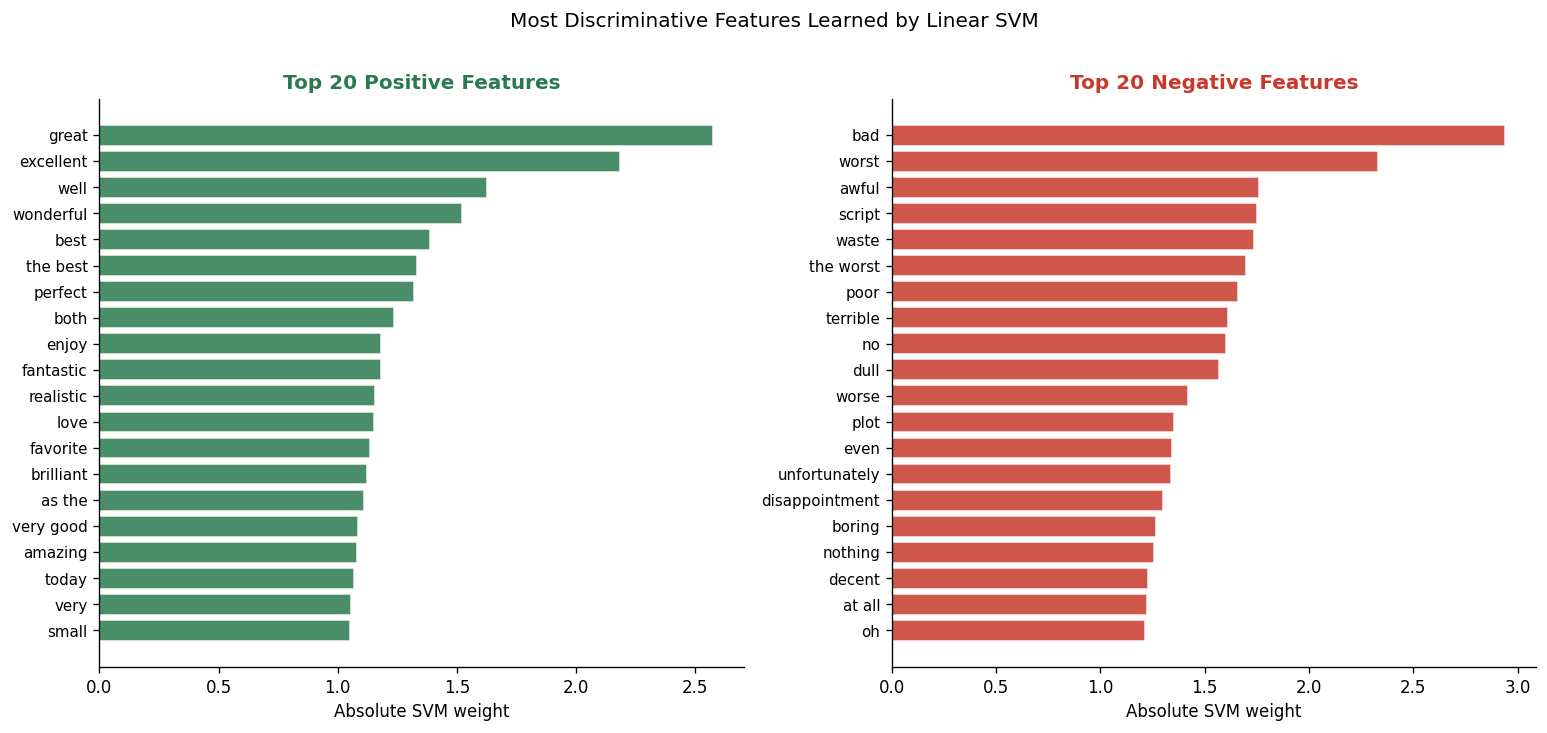

In [49]:
feature_names = best_pipe.named_steps['tfidf'].get_feature_names_out()
coefs         = best_pipe.named_steps['clf'].coef_[0]

N = 20
top_pos_idx = np.argsort(coefs)[-N:][::-1]
top_neg_idx = np.argsort(coefs)[:N]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, idx, color, title in [
    (axes[0], top_pos_idx, COLORS['pos'], 'Top 20 Positive Features'),
    (axes[1], top_neg_idx, COLORS['neg'], 'Top 20 Negative Features'),
]:
    words   = feature_names[idx]
    weights = np.abs(coefs[idx])

    # Sort ascending so largest bar is at top
    sorted_idx = np.argsort(weights)
    words      = words[sorted_idx]
    weights    = weights[sorted_idx]

    ax.barh(words, weights, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(title, fontweight='bold', color=color)
    ax.set_xlabel('Absolute SVM weight')
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Most Discriminative Features Learned by Linear SVM', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/fig_feature_weights.png', bbox_inches='tight', dpi=150)
plt.show()

Most of the top features align well with human intuition.
Words like *"great"*, *"excellent"*, *"wonderful"* dominate the positive side,
while *"bad"*, *"worst"*, *"awful"* lead the negative side.

A few observations worth noting:

**Bigrams appear on both sides.**
*"the best"*, *"very good"* on the positive side and *"the worst"*, *"at all"*
on the negative side confirm that bigrams capture meaningful phrases
that unigrams would split into weaker signals.
*"at all"* is a good example: the word *"all"* alone is nearly neutral,
but *"at all"* frequently appears in dismissive phrases like
*"not good at all"* or *"didn't enjoy it at all"*.

**Some features are surprising.**
*"both"*, *"today"*, *"small"*, and *"realistic"* appear in the top 20 positive features,
which is not immediately intuitive. These likely reflect corpus-specific patterns
rather than genuine sentiment words. For example, *"realistic"* may correlate
with positive reviews of drama films that praise authentic storytelling.

**"no" and "script" are strong negative indicators.**
*"no"* appearing as a top negative feature suggests many negative reviews use
constructions like *"no plot"*, *"no chemistry"*, or *"no reason to watch"*.
*"script"* appearing on the negative side reflects that reviewers frequently
criticise weak writing by name.

### 6.3 Error Analysis

Accuracy tells us how often the model is right.
Error analysis tells us *how* it is wrong, which matters more for understanding
the model's actual limitations.

We sample misclassified reviews and look for recurring patterns.

In [50]:
test_df = X_test.reset_index(drop=True).to_frame(name='review')
test_df['true']      = y_test
test_df['predicted'] = y_pred
test_df['correct']   = test_df['true'] == test_df['predicted']

errors    = test_df[~test_df['correct']]
false_pos = errors[errors['predicted'] == 1]   # negative review predicted as positive
false_neg = errors[errors['predicted'] == 0]   # positive review predicted as negative

print(f'Total errors   : {len(errors)}')
print(f'False positives: {len(false_pos)}  (negative predicted as positive)')
print(f'False negatives: {len(false_neg)}  (positive predicted as negative)')
print()

def show_errors(df, n=3, label=''):
    print(f'{"=" * 60}')
    print(f'  {label}')
    print(f'{"=" * 60}')
    for _, row in df.sample(n, random_state=7).iterrows():
        preview  = row['review'][:400].replace('\n', ' ')
        true_lbl = 'POS' if row['true'] == 1 else 'NEG'
        pred_lbl = 'POS' if row['predicted'] == 1 else 'NEG'
        print(f'[True: {true_lbl}  Predicted: {pred_lbl}]')
        print(preview + ('...' if len(row['review']) > 400 else ''))
        print()

show_errors(false_pos, label='False Positives: negative reviews predicted as positive')
show_errors(false_neg, label='False Negatives: positive reviews predicted as negative')

Total errors   : 118
False positives: 64  (negative predicted as positive)
False negatives: 54  (positive predicted as negative)

  False Positives: negative reviews predicted as positive
[True: NEG  Predicted: POS]
I find it heart-warming and inspiring that the writing team behind such hopelessly mainstream Hollywood movies like INDIANA JONES AND THE TEMPLE OF DOOM, American Graffiti and HOWARD THE DUCK would begin their career with a low-budget exploitation horror film like this. Perhaps as a testament to the talent that would earn Willard Hyuck and Gloria Katz an Oscar nomination later in their respective ...

[True: NEG  Predicted: POS]
Dolph Lundgren stars as Murray Wilson an alcoholic ex-cop who gets involved with a serial killer who kills during sex, after his brother is murdered, Wilson starts his own investigation and finds out a lot of his brother's secrets in this very dull thriller. Lundgren mails in his performance and the movie is flat and lethargic. Also when has anyone 

Out of 1,000 test reviews, 118 are misclassified. Reading through the examples
reveals three recurring patterns:

**Ambiguous framing in false positives.**
The first false positive uses phrases like *"heart-warming"* and *"inspiring"*
in what turns out to be a backhanded compliment about a low-budget horror film.
The model latches onto the positive vocabulary and misses the ironic tone entirely.
The third example is similar: *"strong visual sense"* and *"surreal tradition"*
read as praise on the surface, but the reviewer is actually being critical.

**Neutral or mixed language in false negatives.**
The false negative examples do not use strongly positive vocabulary.
Phrases like *"delightful"* and *"feelgood"* are present but buried among
hedging language and qualifications. The third false negative is the most
interesting: the reviewer uses phrases like *"hate"*, *"borders on suicide"*,
and *"sit through it"* while ultimately recommending the film as a cult hit.
The model reasonably predicts negative given those words.

**A common root cause.**
All three failure modes share the same underlying problem: the model reads
individual words and short phrases, but has no understanding of how those
words are being used in context. Sarcasm, hedging, and ironic praise all
require understanding the *purpose* of language, not just its surface form.
This is a fundamental limitation of bag-of-words representations.

### 7. Bonus

In [54]:
import random
from collections import defaultdict


def build_ngram_lm(texts, n=3):
    """
    Build an n-gram language model from a list of texts.

    For each consecutive sequence of n-1 words (the context),
    record every word that follows it in the corpus.
    At generation time we sample uniformly from the recorded continuations.

    Parameters
    ----------
    texts : list of str
    n     : int — n-gram order (e.g. 3 for trigram model)

    Returns
    -------
    dict mapping tuple(context words) -> list of possible next words
    """
    model = defaultdict(list)
    for text in texts:
        tokens = preprocess(text).split()
        for i in range(len(tokens) - n):
            key       = tuple(tokens[i : i + n - 1])
            next_word = tokens[i + n - 1]
            model[key].append(next_word)
    return model


def generate_text(model, seed, length=30, random_state=None):
    """
    Generate text by repeatedly sampling from the language model.

    Parameters
    ----------
    model        : dict — n-gram language model from build_ngram_lm
    seed         : tuple of str — starting context, length must equal n-1
    length       : int — number of words to generate after the seed
    random_state : int or None — for reproducibility

    Returns
    -------
    str — generated text
    """
    rng   = random.Random(random_state)
    words = list(seed)
    n     = len(seed)
    for _ in range(length):
        key = tuple(words[-n:])
        if key not in model:
            break
        words.append(rng.choice(model[key]))
    return ' '.join(words)


# Build separate models on positive and negative reviews
pos_texts = data[data['sentiment'] == 'positive']['review'].tolist()
neg_texts = data[data['sentiment'] == 'negative']['review'].tolist()

trigram_pos = build_ngram_lm(pos_texts, n=3)
trigram_neg = build_ngram_lm(neg_texts, n=3)

fourgram_pos = build_ngram_lm(pos_texts, n=4)
fourgram_neg = build_ngram_lm(neg_texts, n=4)

print(f'Trigram model  — unique contexts: {len(trigram_pos):,} (pos)  {len(trigram_neg):,} (neg)')
print(f'4-gram model   — unique contexts: {len(fourgram_pos):,} (pos)  {len(fourgram_neg):,} (neg)')

Trigram model  — unique contexts: 246,449 (pos)  233,852 (neg)
4-gram model   — unique contexts: 470,658 (pos)  453,115 (neg)


In [55]:
print('=' * 60)
print('TRIGRAM MODEL — Positive corpus')
print('=' * 60)
for i in range(3):
    print(f'{i+1}. {generate_text(trigram_pos, ("this", "movie"), 25, random_state=i*7)}')

print()
print('=' * 60)
print('TRIGRAM MODEL — Negative corpus')
print('=' * 60)
for i in range(3):
    print(f'{i+1}. {generate_text(trigram_neg, ("this", "movie"), 25, random_state=i*7)}')

print()
print('=' * 60)
print('4-GRAM MODEL — Positive corpus')
print('=' * 60)
for i in range(3):
    print(f'{i+1}. {generate_text(fourgram_pos, ("this", "movie", "was"), 25, random_state=i*7)}')

print()
print('=' * 60)
print('4-GRAM MODEL — Negative corpus')
print('=' * 60)
for i in range(3):
    print(f'{i+1}. {generate_text(fourgram_neg, ("this", "movie", "was"), 25, random_state=i*7)}')

TRIGRAM MODEL — Positive corpus
1. this movie was made in the film to collinwood is nothing more than a little dated now but it is superb then we are promised but it
2. this movie and talked until about am the next morning the version that i momentarily forgot that i had promised to plant a tree the bed etc
3. this movie after all this film not because it does have the key to the farmer thinks they ve just returned from stalingrad is a sydney lawyer

TRIGRAM MODEL — Negative corpus
1. this movie wants to see a good job i m sorry to robert englund is ripping off spy kids which was great but the studio boss but
2. this movie i do not watch this movie is supposed to be good for some laughs because of his material from his armpits and he put together
3. this movie because you ll know its true this was ridiculous we were just horrible the script overly reverts to clich s come out of me the

4-GRAM MODEL — Positive corpus
1. this movie was the best part of filming in combination with the mus

### What This Tells Us

**The two corpora produce noticeably different text.**
Negative-corpus generations include phrases like *"ridiculous"*, *"horrible"*,
*"bad movies"*, and *"i do not watch"*, while positive-corpus generations lean
toward *"superb"*, *"best part"*, *"top notch"*, and *"awesome"*.
This mirrors exactly what we saw in the feature weights from Section 6.2 —
the same vocabulary differences that the classifier exploits are visible
in generated text as well.

**Local coherence improves with larger n.**
Trigram output reads like a random sequence of loosely connected phrases —
sentence 2 of the positive trigram jumps from talking about a movie version
to planting a tree, which makes no sense. 4-gram output occasionally
produces a full clause that sounds plausible, such as
*"this movie was the best part of filming in combination with the music
the director and story told inside it"*. But coherence still breaks down
quickly once the model moves beyond the seed context.

**Sparsity increases sharply with n.**
The trigram model has around 246,000 unique contexts for positive reviews;
the 4-gram model nearly doubles that to 470,000. More unique contexts mean
fewer examples per context, which means generation gets stuck or produces
more erratic jumps. This is the same sparsity problem that explained
why `(1,3)` and `(1,4)` did not help in Experiment B.

**This reveals a fundamental limitation of n-gram models.**
Both the classifier and the language model treat text as a bag of local
co-occurrence statistics. There is no representation of meaning, no memory
of what was said earlier in the review, and no understanding of sentence
structure. This is precisely why transformer-based models like BERT represent
such a large step forward: they maintain context across the entire input
sequence, not just the last n-1 words.

### 8.1 What Worked and Why

The experiments point to three clear conclusions.

**Representation matters more than the classifier.**
The biggest accuracy jump in this project came from switching feature representations,
not from switching classifiers. Moving from BoW to TF-IDF gained about 1 point;
adding bigrams gained another 1.2 points. By contrast, switching from Naive Bayes
to Linear SVM within the same representation gained 2 to 3 points. Combined,
better features and a better classifier took us from 82% to 88.2% — but the
feature side contributed more than the classifier side.

This connects directly to a core idea from the course: the quality of the input
representation sets a ceiling on what any downstream model can learn.
No classifier can recover signal that was never in the features.

**TF-IDF works because sentiment words are distinctive.**
The IDF component of TF-IDF down-weights words that appear in nearly every review —
words like "the", "a", "film", "movie". These words carry no sentiment signal,
so suppressing them lets the classifier focus on words that actually discriminate
between classes. This is why TF-IDF consistently outperforms raw BoW across
every classifier and vocabulary size in Experiment A.

**Bigrams capture what unigrams fragment.**
Feature weight analysis in Section 6.2 confirmed that some of the most
discriminative features are bigrams: "the best", "the worst", "very good", "at all".
These phrases carry sentiment that their individual words do not.
"at all" is the clearest example — the word "all" alone is nearly neutral,
but "at all" almost always appears in a negative context.

### 8.2 Limitations

**The model has no understanding of context.**
Every failure mode identified in Section 6.3 — sarcasm, ironic praise, hedged
positivity — shares the same root cause. The model reads a bag of words,
not a sentence. It has no notion of who is saying what, or whether positive
words are being used sincerely or ironically.

**Negation is handled poorly.**
The preprocessing pipeline keeps words like "not" and "never", and bigrams
like "not good" do appear in the vocabulary. But negation scope is a harder
problem: "this movie was not, in any way I can think of, good" requires
understanding that "not" modifies "good" across a long span.
Bag-of-words and even bigrams cannot capture this reliably.

**The vocabulary is still limited.**
Even at 20,000 features, many words are excluded. Reviews with unusual
vocabulary — technical film terms, foreign words, proper nouns — will be
poorly represented. The model also has no way to handle misspellings or
informal spellings common in online reviews.

**Results may not generalise beyond IMDB.**
The model was trained and tested entirely on IMDB reviews. Sentiment
expressed in tweets, product reviews, or news comments follows different
conventions and vocabulary. Retraining on new domains would likely be
necessary before deploying this approach elsewhere.

### 8.3 What I Would Try Next

**Negation preprocessing.**
Replace negated terms in preprocessing: "not good" → "NOT_good".
This gives negated terms a distinct vocabulary entry, so the model can learn
that "NOT_good" is a negative signal even if "good" is positive.
This is a well-known trick that often recovers 1 to 2 accuracy points
at essentially no additional cost.

**Character n-grams.**
Using `analyzer='char_wb'` in `TfidfVectorizer` captures subword patterns
and handles misspellings naturally. A reviewer who writes "awfulll" or "gr8"
would be better represented by character n-grams than by word tokens.

**More training data.**
The learning curve in Section 5 showed accuracy still climbing at 4,000 examples.
The full IMDB dataset contains 25,000 training reviews — using all of them
with the same pipeline would likely push accuracy above 90% without any
other changes.

**Fine-tuned BERT.**
A transformer model pre-trained on large corpora understands context, negation,
and sentence structure in ways that bag-of-words cannot.
Fine-tuning BERT on IMDB reviews would likely reach 93 to 95% accuracy,
but at the cost of significantly more compute, a more complex training pipeline,
and a much larger model to serve. For a production use case the tradeoff
would need to be evaluated carefully.